In [2]:
from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape

(87, 65)

In [3]:
print('people.images.shape: {}'.format(people.images.shape))
print('Number of classes: {}'.format(len(people.target_names)))

people.images.shape: (3023, 87, 65)
Number of classes: 62


In [7]:
people.keys()

dict_keys(['data', 'images', 'target', 'target_names', 'DESCR'])

In [11]:
import numpy as np

mask = np.zeros(people.target.shape, dtype='bool')
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

X_people = X_people / 255

In [14]:
X_people.shape

(2063, 5655)

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print('Test set score of 1-nn {:.2f}'.format(knn.score(X_test, y_test)))

Test set score of 1-nn 0.22


In [23]:
X_train.shape

(1547, 5655)

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)

print('X_train_pca.shape: {}'.format(X_train_pca.shape))

X_train_pca.shape: (1547, 100)


In [24]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)
print('Test set accuracy: {:.2f}'.format(knn.score(X_test_pca, y_test)))

Test set accuracy: 0.30


In [25]:
print('pca.components_.shape: {}'.format(pca.components_.shape))

pca.components_.shape: (100, 5655)


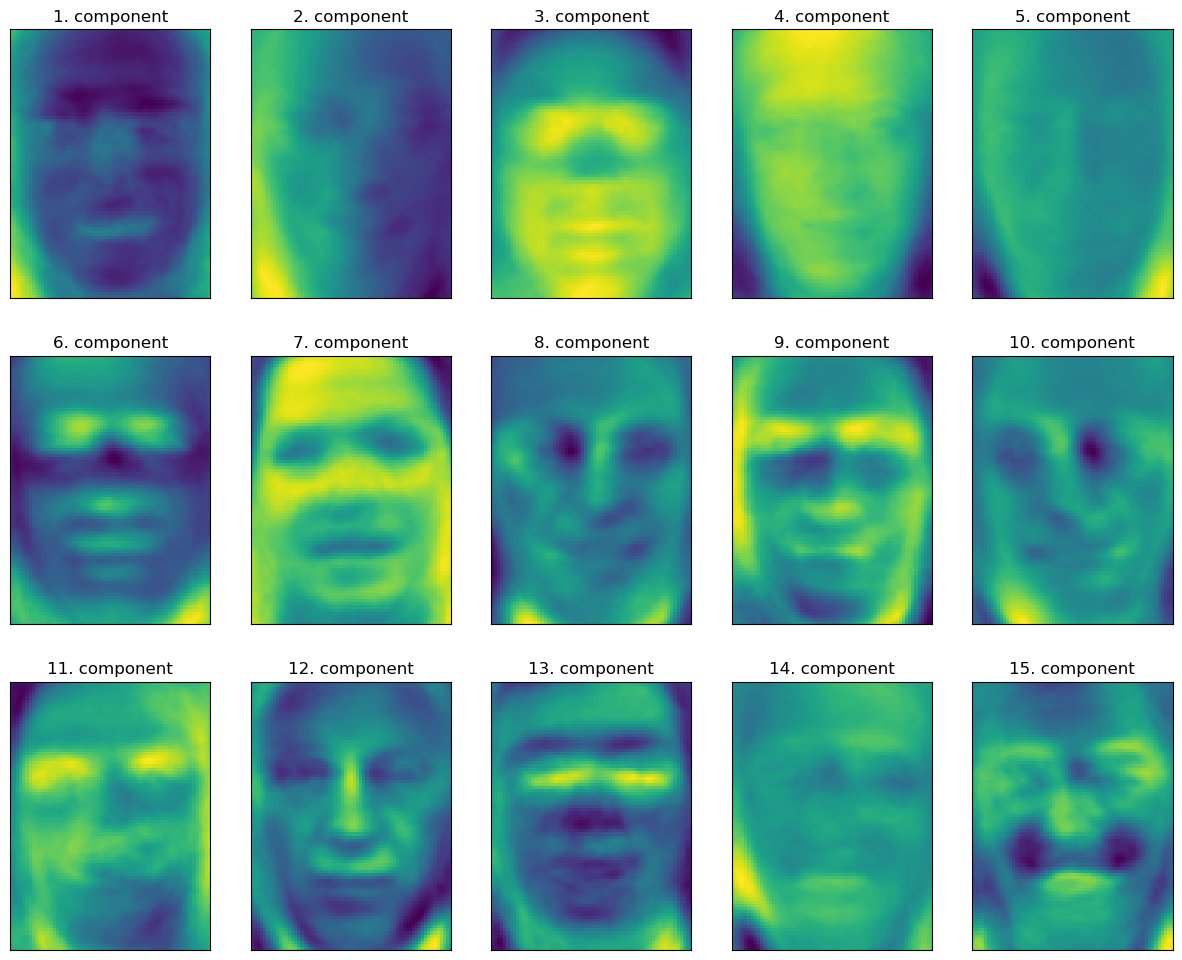

In [27]:
import matplotlib.pyplot as plt

fix, axes = plt.subplots(3, 5, figsize=(15, 12),
                        subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape),
             cmap='viridis')
    ax.set_title('{}. component'.format((i + 1)))